---

<center><h3></h3><h3><b>Comparação entre Vision Transformers e U-Net com MobileNetV2 na Segmentação de Exsudatos Lipídicos em Imagens de Retinografia

</b></h3></center>

Este notebook apresenta a análise das metodologias de segmentação de imagens de fundo de olho no diagnóstico de retinopatia diabética, como resultado do projeto final do Trabalho de Conclusão de Curso em Engenharia Elétrica pela Universidade Federal do Ceará (UFC).

Autor: Pedro Florencio
<br>Contato: <i>pedroflorencio@edu.unifor.br</i>

---



<!-- Python -->
<a href="https://www.python.org/downloads/release/python-3100/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/python-3.10-green" alt="Python Version" title="Python Version" height="20">
</a>

<!-- TensorFlow -->
<a href="https://www.tensorflow.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/TensorFlow-2.x-FF6F00?logo=tensorflow&logoColor=white" alt="TensorFlow" title="TensorFlow" height="20">
</a>

<!-- OpenCV -->
<a href="https://opencv.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/OpenCV-4.x-blue?logo=opencv&logoColor=white" alt="OpenCV" title="OpenCV" height="20">
</a>

<!-- scikit-image -->
<a href="https://scikit-image.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/scikit--image-0.21-orange?logo=scikit-learn&logoColor=white" alt="scikit-image" title="scikit-image" height="20">
</a>

<!-- Licença Creative Commons -->
<a href="https://creativecommons.org/licenses/by-nd/4.0/" target="_blank" style="margin-right:12px;">
  <img align="left" src="https://licensebuttons.net/l/by-nd/4.0/88x31.png" alt="Creative Commons BY-ND 4.0" title="Creative Commons BY-ND 4.0" height="20">
</a>

In [ ]:
# GPU
!nvidia-smi

# CPU
!cat /proc/cpuinfo | grep "model name" | uniq

# Memória RAM
!cat /proc/meminfo | grep MemTotal

Mon Jan 26 07:52:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### **1. Bibliotecas**


In [ ]:
!pip install -q torch torchvision transformers datasets pillow scikit-learn numpy

In [ ]:
import os
import cv2
import torch
import numpy as np
from glob import glob
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import seaborn as sns
import albumentations as A
from torch.optim import AdamW
import torch.nn.functional as F
import matplotlib.pyplot as plt
from google.colab import userdata
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import MobileViTForSemanticSegmentation, MobileViTImageProcessor

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


#### **2. Parâmetros**

In [ ]:
BASE_DRIVE = '/gdrive/MyDrive/Lumina/Data/A. Segmentation'

PATHS = {
    'train': {
        'img': '/gdrive/MyDrive/Lumina/Data/A. Segmentation/1. Original Images/a. Training Set/',
        'mask': '/gdrive/MyDrive/Lumina/Data/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/'
    },
    'test': {
        'img': '/gdrive/MyDrive/Lumina/Data/A. Segmentation/1. Original Images/b. Testing Set/',
        'mask': '/gdrive/MyDrive/Lumina/Data/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/3. Hard Exudates/'
    }
}

PATCH_SIZE = 256
STRIDE = 256
OUTPUT_DIR = "/content/IDRiD_Patches"
HF_TOKEN = userdata.get('HF_TOKEN')
MODEL_CHECKPOINT = "apple/mobilevit-small"
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4

#### **3. Pré-Processamento das Imagens**

In [ ]:
def process_dataset(split_type):
    print(f"--- Processando {split_type.upper()} ---")

    img_dir = PATHS[split_type]['img']
    mask_dir = PATHS[split_type]['mask']

    # Listar todas as imagens JPG
    image_files = sorted(glob(os.path.join(img_dir, "*.jpg")))

    save_img_dir = os.path.join(OUTPUT_DIR, split_type, "images")
    save_mask_dir = os.path.join(OUTPUT_DIR, split_type, "masks")
    os.makedirs(save_img_dir, exist_ok=True)
    os.makedirs(save_mask_dir, exist_ok=True)

    count_saved = 0

    for img_path in tqdm(image_files):
        filename = os.path.basename(img_path)
        name_no_ext = os.path.splitext(filename)[0]
        mask_name_tif = f"{name_no_ext}_EX.tif"
        mask_name_png = f"{name_no_ext}_EX.png"

        full_mask_path = os.path.join(mask_dir, mask_name_tif)

        if not os.path.exists(full_mask_path):
            # Tenta opção PNG se TIF não existir
            full_mask_path = os.path.join(mask_dir, mask_name_png)
            if not os.path.exists(full_mask_path):
                print(f"AVISO: Máscara não encontrada para {filename}. Pulando.")
                continue



        img = cv2.imread(img_path)
        mask = cv2.imread(full_mask_path, 0)

        if img is None or mask is None:
            continue

        mask = np.where(mask > 0, 1, 0).astype(np.uint8)

        h, w, _ = img.shape

        idx_patch = 0
        for y in range(0, h - PATCH_SIZE + 1, STRIDE):
            for x in range(0, w - PATCH_SIZE + 1, STRIDE):
                patch_img = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                patch_mask = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                has_exudates = np.sum(patch_mask) > 0

                keep_patch = False
                if split_type == 'test':
                    keep_patch = True
                else:
                    if has_exudates:
                        keep_patch = True
                    elif np.random.rand() < 0.05:
                        keep_patch = True

                if keep_patch:
                    save_name = f"{name_no_ext}_{idx_patch}.png"
                    cv2.imwrite(os.path.join(save_img_dir, save_name), patch_img)
                    cv2.imwrite(os.path.join(save_mask_dir, save_name), patch_mask)
                    count_saved += 1

                idx_patch += 1

    print(f"Total de patches gerados para {split_type}: {count_saved}")

process_dataset('train')
process_dataset('test')

--- Processando TRAIN ---


100%|██████████| 54/54 [02:26<00:00,  2.71s/it]


Total de patches gerados para train: 2078
--- Processando TEST ---


100%|██████████| 27/27 [01:20<00:00,  2.96s/it]

Total de patches gerados para test: 4752


In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GridDistortion(p=0.2),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


#### **4. Modelagem do Dataset**

In [ ]:
class IDRIDPatchDataset(Dataset):
    def __init__(self, root_dir, split, processor, transform=None):
        self.img_dir = os.path.join(root_dir, split, "images")
        self.mask_dir = os.path.join(root_dir, split, "masks")

        self.files = sorted(os.listdir(self.img_dir))
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        img_path = os.path.join(self.img_dir, file_name)
        mask_path = os.path.join(self.mask_dir, file_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image_np = np.array(image)
        mask_np = np.array(mask)

        if self.transform:
            augmented = self.transform(image=image_np, mask=mask_np)
            image_np = augmented['image']
            mask_np = augmented['mask']

        inputs = self.processor(
            images=image_np,
            segmentation_maps=mask_np,
            return_tensors="pt"
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        return inputs

In [ ]:
processor = MobileViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)
train_ds = IDRIDPatchDataset(OUTPUT_DIR, 'train', processor, transform=train_transform)
test_ds = IDRIDPatchDataset(OUTPUT_DIR, 'test', processor, transform=None) # Sem augmentação no teste!

preprocessor_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):

        inputs = F.softmax(inputs, dim=1)
        inputs = inputs[:, 1, :, :].contiguous().view(-1)
        targets = targets.contiguous().view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)

        return 1 - dice

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

In [ ]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, inputs, targets):

        probs = F.softmax(inputs, dim=1)
        inputs = probs[:, 1, :, :].contiguous().view(-1)
        targets = targets.contiguous().view(-1)

        TP = (inputs * targets).sum()
        FP = ((1 - targets) * inputs).sum()
        FN = (targets * (1 - inputs)).sum()

        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)

        return 1 - tversky

#### **5. Treinamento**

In [ ]:
def calculate_metrics(pred_tensor, target_tensor, class_index=1):
    """
    Calcula IoU e Dice para uma classe específica (1 = Exsudatos).
    pred_tensor: (Batch, H, W) com 0s e 1s
    target_tensor: (Batch, H, W) com 0s e 1s
    """
    pred_flat = pred_tensor.view(-1)
    target_flat = target_tensor.view(-1)

    pred_class = (pred_flat == class_index)
    target_class = (target_flat == class_index)

    intersection = (pred_class & target_class).sum().float()

    pred_sum = pred_class.sum().float()
    target_sum = target_class.sum().float()

    union = pred_sum + target_sum - intersection

    smooth = 1e-6

    iou = (intersection + smooth) / (union + smooth)
    dice = (2. * intersection + smooth) / (pred_sum + target_sum + smooth)

    return iou.item(), dice.item()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Iniciando treino em: {device}")

# --- CONFIGURAÇÃO DO EARLY STOPPING ---
PATIENCE = 7
patience_counter = 0

# Instanciando o modelo
model = MobileViTForSemanticSegmentation.from_pretrained(MODEL_CHECKPOINT, num_labels=2, ignore_mismatched_sizes=True)
model.to(device)

# Pesos para CrossEntropy
class_weights = torch.tensor([1.0, 10.0]).to(device)

# Instanciando as Loss Functions testadas
criterion_ce = nn.CrossEntropyLoss(weight=class_weights)
criterion_dice = DiceLoss()
criterion_focal = FocalLoss(alpha=0.8, gamma=2.0)
criterion_tversky = TverskyLoss(alpha=0.3, beta=0.7)

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Histórico para gráficos
history = {
    'train_loss': [], 'train_iou': [], 'train_dice': [],
    'val_loss': [], 'val_iou': [], 'val_dice': []
}

best_val_dice = 0.0

# Instantiate DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. CICLO DE TREINO E VALIDAÇÃO (LOOP)
# ==========================================

for epoch in range(EPOCHS):
    # --- FASE DE TREINO ---
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for batch in train_bar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Forward Pass
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits

        # Redimensionar Logits
        logits = F.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Calcular Loss Tversky
        loss = criterion_tversky(logits, labels)

        # Backward
        loss.backward()
        optimizer.step()

        # Métricas
        with torch.no_grad():
            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            preds = (probs > 0.4).float()
            iou, dice = calculate_metrics(preds, labels, class_index=1)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        train_bar.set_postfix(loss=loss.item(), dice=dice)

    # Médias de Treino
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_iou = running_iou / len(train_loader)
    epoch_train_dice = running_dice / len(train_loader)

    history['train_loss'].append(epoch_train_loss)
    history['train_dice'].append(epoch_train_dice)
    history['train_iou'].append(epoch_train_iou)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    print(f"Época {epoch+1} finalizada. LR atual: {current_lr:.8f}")

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0

    count_valid_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=labels.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            # Loss de validação (Monitoramento)
            loss_v = criterion_tversky(logits, labels)
            val_loss += loss_v.item()

            # Predição para métricas
            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            preds = (probs > 0.4).float()

            if labels.sum() > 0:
                iou, dice = calculate_metrics(preds, labels, class_index=1)
                val_iou += iou
                val_dice += dice
                count_valid_batches += 1

    # Médias de Validação
    epoch_val_loss = val_loss / len(test_loader)

    # Se nenhum batch válido foi encontrado (improvável), evita divisão por zero
    if count_valid_batches > 0:
        epoch_val_iou = val_iou / count_valid_batches
        epoch_val_dice = val_dice / count_valid_batches
    else:
        epoch_val_iou = 0.0
        epoch_val_dice = 0.0

    history['val_loss'].append(epoch_val_loss)
    history['val_dice'].append(epoch_val_dice)
    history['val_iou'].append(epoch_val_iou)

    print(f"\nRESUMO EPOCH {epoch+1}:")
    print(f"Train -> Loss: {epoch_train_loss:.4f} | Dice: {epoch_train_dice:.4f}")
    print(f"Val   -> Loss: {epoch_val_loss:.4f}   | Dice: {epoch_val_dice:.4f}")

    # ==========================================
    # LÓGICA DE SAVE + EARLY STOPPING
    # ==========================================

    # Verifica se melhorou o Dice de Validação
    if epoch_val_dice > best_val_dice:
        print(f"--> Melhora detectada ({best_val_dice:.4f} -> {epoch_val_dice:.4f}). Salvando modelo...")
        best_val_dice = epoch_val_dice
        patience_counter = 0 # Resetar paciência pois melhorou

        save_path = "/gdrive/MyDrive/Lumina/Models/Best_MobileViT_IDRID"
        model.save_pretrained(save_path)
        processor.save_pretrained(save_path)
    else:
        patience_counter += 1
        print(f"--> Sem melhora. Paciência: {patience_counter}/{PATIENCE}")

        # Condição de Parada
        if patience_counter >= PATIENCE:
            print("\n" + "="*50)
            print(f"EARLY STOPPING ATIVADO NA ÉPOCA {epoch+1}!")
            print(f"O modelo não melhora há {PATIENCE} épocas. Parando treino.")
            print("="*50)
            break # Encerra o loop 'for epoch'

    print("-" * 50)

Iniciando treino em: cuda


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Some weights of MobileViTForSemanticSegmentation were not initialized from the model checkpoint at apple/mobilevit-small and are newly initialized: ['segmentation_head.aspp.convs.0.convolution.weight', 'segmentation_head.aspp.convs.0.normalization.bias', 'segmentation_head.aspp.convs.0.normalization.num_batches_tracked', 'segmentation_head.aspp.convs.0.normalization.running_mean', 'segmentation_head.aspp.convs.0.normalization.running_var', 'segmentation_head.aspp.convs.0.normalization.weight', 'segmentation_head.aspp.convs.1.convolution.weight', 'segmentation_head.aspp.convs.1.normalization.bias', 'segmentation_head.aspp.convs.1.normalization.num_batches_tracked', 'segmentation_head.aspp.convs.1.normalization.running_mean', 'segmentation_head.aspp.convs.1.normalization.running_var', 'segmentation_head.aspp.convs.1.normalization.weight', 'segmentation_head.aspp.convs.2.convolution.weight', 'segmentation_head.aspp.convs.2.normalization.bias', 'segmentation_head.aspp.convs.2.normalization

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

...


RESUMO EPOCH 26:
Train -> Loss: 0.3155 | Dice: 0.6328
Val   -> Loss: 0.6619   | Dice: 0.4844
--> Sem melhora. Paciência: 6/7
--------------------------------------------------


Epoch 27/30 [Train]: 100%|██████████| 261/261 [00:40<00:00,  6.39it/s, dice=0.403, loss=0.53]


Época 27 finalizada. LR atual: 0.00000245


Epoch 27/30 [Val]: 100%|██████████| 594/594 [00:43<00:00, 13.74it/s]


RESUMO EPOCH 27:
Train -> Loss: 0.3230 | Dice: 0.6248
Val   -> Loss: 0.6598   | Dice: 0.4947
--> Sem melhora. Paciência: 7/7

EARLY STOPPING ATIVADO NA ÉPOCA 27!
O modelo não melhora há 7 épocas. Parando treino.


#### **6. Avaliação**

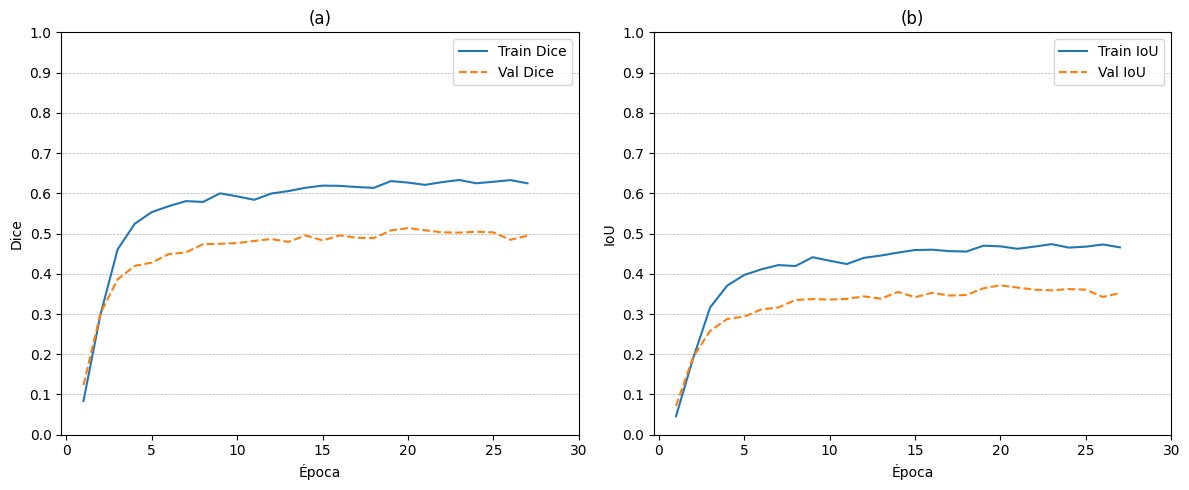

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de DICE
plt.subplot(1, 2, 1) # Agora 1 linha, 2 colunas, 1º gráfico
plt.plot(epochs_range, history['train_dice'], label='Train Dice')
plt.plot(epochs_range, history['val_dice'], label='Val Dice', linestyle='--')
plt.title('(a)')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.yticks(np.arange(0,1.1,.1))
plt.xticks(np.arange(0,31,5))

# Gráfico de IoU
plt.subplot(1, 2, 2) # Agora 1 linha, 2 colunas, 2º gráfico
plt.plot(epochs_range, history['train_iou'], label='Train IoU')
plt.plot(epochs_range, history['val_iou'], label='Val IoU', linestyle='--')
plt.title('(b)')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.yticks(np.arange(0,1.1,.1))
plt.xticks(np.arange(0,31,5))

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [ ]:
max_dice_index = history['val_dice'].index(max(history['val_dice']))
final_best_dice = history['val_dice'][max_dice_index]
final_best_iou = history['val_iou'][max_dice_index]

print(f"--- Métricas do Modelo Salvo ---")
print(f"Dice Score (Validação): {final_best_dice:.4f}")
print(f"IoU (Validação): {final_best_iou:.4f}")
# print(f"Tempo de Inferência por Imagem (média): {avg_inference_time_per_image:.4f} segundos")

--- Métricas do Modelo Salvo ---
Dice Score (Validação): 0.5133
IoU (Validação): 0.3712


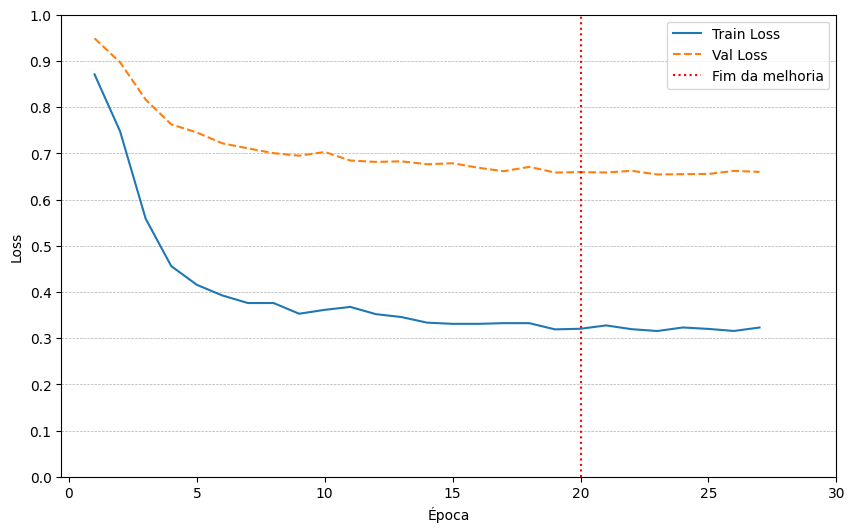

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', linestyle='--')
plt.title('')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
# grid mais fina e com linha tracejada
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.yticks(np.arange(0,1.1,.1))
plt.xticks(np.arange(0,31,5))
epoch_no_improvement_start = 20
plt.axvline(x=epoch_no_improvement_start, color='r', linestyle=':', label='Fim da melhoria')
plt.legend()

plt.show()